## Title master thesis
# “Research Question”

---
**Authors:** Leonard Rampf, Niklas Keckeisen

**Advisors:** Michail Batikas

**Submission Date:** 21.05.2026

# Table of Contents
- [1. Data Preparation](#3.-data-preparation)
  - [1.1 Data Loading](#3.1-data-loading)
  - [1.2 Data Cleaning](#3.2-data-cleaning)
  - [1.3. Investigation and Dropping of Irrelevant Columns](#3.3.-investigation-and-dropping-of-irrelevant-columns)
  - [1.4 Conversion of values](#3.4-conversion-of-values)

- [2. Exploratory data analysis (EDA)](#4.-exploratory-data-analysis-eda)
  - [2.1 Descriptive Statistics](#4.1-descriptive-statistics)
  - [2.2 Skewness and Kurtosis](#4.2-skewness-and-kurtosis)
  - [2.3 CDF's](#4.3-cdfs)
  - [4.4 Outliers](#4.4-outliers)
  - [4.5 Data Transformation](#4.5-data-transformation)
    - [4.5.1 Box-Cox Transformation](#4.5.1-box-cox-transformation)
    - [4.5.2 Log Transformation](#4.5.2-log-transformation)
    - [4.5.3 Verification of Transformation](#4.5.3-verification-of-transformation)
  - [4.6 Multivariate Overview & Interpretation](#4.6-multivariate-overview--interpretation)
  - [4.7 Preliminary Hypothesis Exploration](#4.7-preliminary-hypothesis-exploration)
    - [4.7.1 Income vs Job Level](#4.7.1-income-vs-job-level)
    - [4.7.2 Income vs Years Worked](#4.7.2-income-vs-years-worked)
    - [4.7.3 Income vs NumCompaniesWorked](#4.7.3-income-vs-numcompaniesworked)
    - [4.7.4 NumCompaniesWorked vs Job Satisfaction](#4.7.4-numcompaniesworked-vs-job-satisfaction)

- [5. Hypothesis 1](#5.-does-job-hopping-have-any-effect-on-income)

# Introduction

Short Introduction
Statement of Research Question

Hypothesis

# Data Preparation

## Import Statements

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
import os
import json
from scipy.stats import wilcoxon, norm, kruskal
from statsmodels.stats.multitest import multipletests

## Data Loading

In [3]:
relative_path = os.path.join("..", "..", "data", "retail", "retrieval", "20260413_retrieval_results_geo_v2.csv")
input_file = os.path.abspath(relative_path)

df = pd.read_csv(input_file)

## Data Investigation

In [4]:
df.head()

,query_id,query,doc_id,method,doc_text,rank,is_target
0,50881_doc,holidaytraditions,50881_doc_comp_2,default_method,Name: HolidayTraditions State Trooper Personal...,1,0
1,50881_doc,holidaytraditions,50881_doc_comp_3,default_method,Name: Personalized Christmas Ornaments Family ...,2,0
2,50881_doc,holidaytraditions,50881_doc_comp_9,default_method,Name: Personalized Christmas Ornaments Family ...,3,0
3,50881_doc,holidaytraditions,50881_doc_TARGET,default_method,Name: Personalized Christmas Ornaments 2020 – ...,4,1
4,50881_doc,holidaytraditions,50881_doc_comp_1,default_method,Name: Kids Christmas Ornaments 2021 – Personal...,5,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109875 entries, 0 to 109874
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   query_id   109875 non-null  object
 1   query      109875 non-null  object
 2   doc_id     109875 non-null  object
 3   method     109875 non-null  object
 4   doc_text   109875 non-null  object
 5   rank       109875 non-null  int64 
 6   is_target  109875 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 5.9+ MB


In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


In [7]:
print(f"Number of unique values in 'query_id': {df['query_id'].nunique()}")
print(f"Number of unique values in 'query': {df['query'].nunique()}")
print(f"Number of unique values in 'doc_id': {df['doc_id'].nunique()}")
print(f"Number of unique values in 'method': {df['method'].nunique()}")
print(f"Number of unique values in 'doc_text': {df['doc_text'].nunique()}")
print(f"Number of unique values in 'rank': {df['rank'].nunique()}")
print(f"Number of unique values in 'is_target': {df['is_target'].nunique()}")

Number of unique values in 'query_id': 11000
Number of unique values in 'query': 500
Number of unique values in 'doc_id': 109875
Number of unique values in 'method': 1
Number of unique values in 'doc_text': 15089
Number of unique values in 'rank': 10
Number of unique values in 'is_target': 2


## Data Preprocessing

First we will look at the 15 errors with missing target documents that were identified in the retrieval stage. Ghost targets are marked and penalized with a rank of k + 1, where k is the max number of documents in a query_id. 

In [8]:
# 1. FILE CONFIGURATION
jsonl_relative_path = os.path.join("..", "..", "data", "retail", "retrieval", "20260413_vertex_geoedits_v1.jsonl") 
jsonl_baseline_path = os.path.abspath(jsonl_relative_path)

def inject_ghost_targets_with_jsonl(df):
    print("Scanning for Missing Targets...")
    
    # 1. Find the missing queries
    all_queries = df['query_id'].unique()
    queries_with_targets = df[df['is_target'] == 1]['query_id'].unique()
    missing_target_queries = set(all_queries) - set(queries_with_targets)
    
    print(f"Found {len(missing_target_queries)} queries missing their Target document.")
    
    if len(missing_target_queries) > 0:
        # 2. Extract the true query text, doc_id, and doc_text from the JSONL
        print("Mapping original text and target details from JSONL baseline...")
        target_map = {}
        
        with open(jsonl_baseline_path, 'r', encoding='utf-8') as file:
            for line in file:
                record = json.loads(line.strip())
                
                doc_id = record.get("id", "")
                struct_data = record.get("structData", {})
                q_id = struct_data.get("query_id")
                
                if q_id in missing_target_queries:
                    if "TARGET" in doc_id.upper():
                        target_map[q_id] = {
                            "query": struct_data.get("original_query", "UNMAPPED"),
                            "doc_id": doc_id,
                            "text": struct_data.get("text", "N/A") 
                        }

        # 3. Create the penalized rows with true context
        ghost_rows = []
        for q_id in missing_target_queries:
            # Retrieve the mapped data, with a safety fallback
            mapped_data = target_map.get(q_id, {
                "query": "UNMAPPED", 
                "doc_id": "GHOST_TARGET_NOT_FOUND_IN_JSONL", 
                "text": "TEXT_NOT_FOUND"
            }) 
            
            ghost_rows.append({
                "query_id": q_id,
                "query": mapped_data["query"],
                "doc_id": mapped_data["doc_id"],       
                "method": "imputed_penalty",
                "doc_text": mapped_data["text"],       
                "rank": 11,                            # THE PENALTY
                "is_target": 1
            })
            
        ghost_df = pd.DataFrame(ghost_rows)
        
        # 4. Inject and Return
        df_final = pd.concat([df, ghost_df], ignore_index=True)
        print("Injection complete.")
        return df_final
        
    else:
        print("No missing targets found. The dataset is already perfectly intact.")
        return df
        
df2 = inject_ghost_targets_with_jsonl(df)

Scanning for Missing Targets...
Found 15 queries missing their Target document.
Mapping original text and target details from JSONL baseline...
Injection complete.


Lets display and see if the injection worked properly

In [9]:
# Filter the dataframe for the exact flag we used for the Ghost Targets
ghost_cases = df2[df2['method'] == 'imputed_penalty']

# 1. Verify the count
print(f"Total Ghost Cases Confirmed in Dataframe: {len(ghost_cases)}")

# 2. Visually inspect the critical columns
display_cols = ['query_id', 'query', 'doc_id', 'rank', 'doc_text']

# Using .head(15) just to cleanly print all of them to your notebook screen
display(ghost_cases[display_cols].head(15))

Total Ghost Cases Confirmed in Dataframe: 15


,query_id,query,doc_id,rank,doc_text
109875,58302_Authoritative(doc),king led,58302_Authoritative_doc__TARGET,11,Name: 1200w LED Grow Light with Veg&Bloom Swit...
109876,54484_FCQS(doc),iphone plus 8 charger case,54484_FCQS_doc__TARGET,11,**Product Name:** VICSEED Car Phone Mount - Ma...
109877,54484_LLMstxt(doc),iphone plus 8 charger case,54484_LLMstxt_doc__TARGET,11,```markdown\n# VICSEED Super Strong Magnet Pow...
109878,8070_Fluency(doc),all clad measuring cups and spoons,8070_Fluency_doc__TARGET,11,Name: Measuring Spoons: U-Taste 18/8 Stainless...
109879,94478_FQ(doc),slip absorbent door mat outdoor,94478_FQ_doc__TARGET,11,**Product Name:** Indoor Door Mat - Front Door...
109880,28024_Quotes(doc),combed cotton sheet,28024_Quotes_doc__TARGET,11,Name: 300 Thread Count Jacquard Polka Dot Dark...
109881,905_FCQS(doc),1 way window film,905_FCQS_doc__TARGET,11,**Product Name:** rabbitgoo Window Privacy Fil...
109882,28384_FQS(doc),computer repair tool kit,28384_FQS_doc__TARGET,11,**Name:** Kaisi 126 in 1 Precision Screwdriver...
109883,97137_Statistics(doc),sprout lids,97137_Statistics_doc__TARGET,11,Name: Dergo 4 in 1 Quick Knot Cutter Nippers S...
109884,75438_CS(doc),oliccty cheesecloth,75438_CS_doc__TARGET,11,"Name: NUOBUNG - Cheesecloth, Grade 90, 100% Un..."


## Descriptive Analysis

In [10]:
# Remove the column limit and widen display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Strictly isolate the target documents
targets = df2[df2['is_target'] == 1].copy()

# The order here is mathematically critical to prevent overlapping abbreviations
dimension_hierarchy = [
    ('ContentImprovement', 'Content Improvement'),
    ('SimpleLanguage', 'Simple Language'),
    ('TechnicalTerms', 'Technical Terms'),
    ('UniqueWords', 'Unique Words'),
    ('Authoritative', 'Authoritative'),
    ('Statistics', 'Statistics'),
    ('Citations', 'Citations'),
    ('Fluency', 'Fluency'),
    ('LLMstxt', 'LLMs text'),
    ('Quotes', 'Quotes'),
    ('FCQS', 'Fluency, Citation, Quotes, Statistics'),
    ('FCQ', 'Fluency, Citation, Quotes'), ('FCS', 'Fluency, Citation, Statistics'), ('FQS', 'Fluency, Quotes, Statistics'), ('CQS', 'Citation, Quotes, Statistics'),
    ('FC', 'Fluency, Citation'), ('FQ', 'Fluency, Quotes'), ('FS', 'Fluency, Statistics'), ('CQ', 'Citation, Quotes'), ('CS', 'Citation, Statistics'), ('QS', 'Quotes, Statistics')
]

def extract_dimension(qid):
    if "doc" in qid and "(doc)" not in qid:
        return "Baseline"
    for key, label in dimension_hierarchy:
        if key in qid:
            return label
    return "Unknown"

targets['dimension'] = targets['query_id'].apply(extract_dimension)
targets['base_id'] = targets['query_id'].str.split('_').str[0]


# PART 2: PAIRING BASELINE WITH EDITED RUNS

baseline_df = targets[targets['dimension'] == 'Baseline'][['base_id', 'rank']].rename(columns={'rank': 'baseline_rank'})
edited_df = targets[targets['dimension'] != 'Baseline'][['base_id', 'dimension', 'rank']].rename(columns={'rank': 'edited_rank'})
paired_df = pd.merge(edited_df, baseline_df, on='base_id', how='inner')

# Calculate the rank shift (Positive = Improved visibility)
paired_df['rank_shift'] = paired_df['baseline_rank'] - paired_df['edited_rank']

# Calculate Reciprocal Ranks for MRR
paired_df['RR_Baseline'] = 1.0 / paired_df['baseline_rank']
paired_df['RR_Edited'] = 1.0 / paired_df['edited_rank']

def categorize(row):
    if row['edited_rank'] == 11: return 'Missing'
    elif row['rank_shift'] > 0: return 'Improved'
    elif row['rank_shift'] < 0: return 'Worsened'
    else: return 'Unchanged'

paired_df['status'] = paired_df.apply(categorize, axis=1)


# PART 3: THE MASTER DESCRIPTIVE AGGREGATION

def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)
def iqr(x): return x.quantile(0.75) - x.quantile(0.25)
def top_3_pct(x): return (x <= 3).mean() * 100

summary = paired_df.groupby('dimension').agg(
    N=('base_id', 'count'),
    
    # Distribution Metrics
    Median_Baseline=('baseline_rank', 'median'),
    Median_Edited=('edited_rank', 'median'),
    Median_Shift=('rank_shift', 'median'),
    Mean_Baseline=('baseline_rank', 'mean'),
    Mean_Edited=('edited_rank', 'mean'),
    Mean_Shift=('rank_shift', 'mean'),
    Q25_Baseline=('baseline_rank', q25),
    Q25_Edited=('edited_rank', q25),
    Q75_Baseline=('baseline_rank', q75),
    Q75_Edited=('edited_rank', q75),
    IQR_Baseline=('baseline_rank', iqr),
    IQR_Edited=('edited_rank', iqr), 
    
    # Performance Metrics
    Top3_Baseline_Pct=('baseline_rank', top_3_pct),
    Top3_Edited_Pct=('edited_rank', top_3_pct),
    MRR_Baseline=('RR_Baseline', 'mean'),
    MRR_Edited=('RR_Edited', 'mean')
)

status_counts = paired_df.groupby(['dimension', 'status']).size().unstack(fill_value=0)
count_missing = status_counts[['Missing']].rename(columns={'Missing': 'Count_Missing'})
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100

for col in ['Improved', 'Worsened', 'Unchanged', 'Missing']:
    if col not in status_pct.columns:
        status_pct[col] = 0.0

status_pct = status_pct.rename(columns={
    'Improved': '% Improved', 
    'Worsened': '% Worsened', 
    'Unchanged': '% Unchanged', 
    'Missing': '% Missing'
})

master_table = summary.join(count_missing).join(status_pct)

# Clean up column names and calculate Deltas
master_table = master_table.rename(columns={
    'Top3_Edited_Pct': '% Top3_Edited', 
    'Top3_Baseline_Pct': '% Top3_Baseline'
})
master_table['% Top3_Delta'] = master_table['% Top3_Edited'] - master_table['% Top3_Baseline']
master_table['MRR_Shift'] = master_table['MRR_Edited'] - master_table['MRR_Baseline']


# PART 4: SPLITTING INTO TWO CLEAN TABLES

# Table 1: Distribution Table
table_1_columns = [
    'N', 'Median_Baseline', 'Median_Edited', 'Median_Shift', 
    'Mean_Baseline', 'Mean_Edited', 'Mean_Shift', 
    'Q25_Baseline', 'Q25_Edited', 'Q75_Baseline', 'Q75_Edited', 
    'IQR_Baseline', 'IQR_Edited', 'Count_Missing'
]
distribution_table = master_table[table_1_columns].sort_values(by=['Median_Shift', 'Mean_Shift'], ascending=[False, False])

# Table 2: Ranking Performance Table
table_2_columns = [
    'N', 'MRR_Baseline', 'MRR_Edited', 'MRR_Shift', 
    '% Top3_Baseline', '% Top3_Edited', '% Top3_Delta', 
    '% Improved', '% Unchanged', '% Worsened', '% Missing'
]
# Sorting by MRR Shift since it's the strongest indicator of ranking performance
ranking_table = master_table[table_2_columns].sort_values(by=['MRR_Shift', '% Top3_Delta'], ascending=[False, False])


# Format and Display
print("--- TABLE 1: DISTRIBUTION SUMMARY ---")
display(distribution_table.round(2))

print("\n\n--- TABLE 2: RANKING PERFORMANCE SUMMARY ---")
display(ranking_table.round(4)) # Rounding to 4 here because MRR differences can be subtle decimal shifts

--- TABLE 1: DISTRIBUTION SUMMARY ---


,N,Median_Baseline,Median_Edited,Median_Shift,Mean_Baseline,Mean_Edited,Mean_Shift,Q25_Baseline,Q25_Edited,Q75_Baseline,Q75_Edited,IQR_Baseline,IQR_Edited,Count_Missing
dimension,,,,,,,,,,,,,,
Simple Language,500,6.0,6.0,0.0,5.54,5.54,-0.01,3.0,3.0,8.0,8.0,5.0,5.0,0
Citations,500,6.0,6.0,0.0,5.54,5.65,-0.12,3.0,3.0,8.0,8.0,5.0,5.0,0
Quotes,500,6.0,6.0,0.0,5.54,5.68,-0.14,3.0,3.0,8.0,8.0,5.0,5.0,1
Technical Terms,500,6.0,6.0,0.0,5.54,5.73,-0.19,3.0,3.0,8.0,8.0,5.0,5.0,0
"Quotes, Statistics",500,6.0,6.0,0.0,5.54,5.75,-0.21,3.0,3.0,8.0,8.0,5.0,5.0,0
Authoritative,500,6.0,6.0,0.0,5.54,5.75,-0.22,3.0,3.0,8.0,8.0,5.0,5.0,1
"Citation, Statistics",500,6.0,6.0,0.0,5.54,5.78,-0.24,3.0,3.0,8.0,8.0,5.0,5.0,1
Unique Words,500,6.0,6.0,0.0,5.54,5.80,-0.26,3.0,3.0,8.0,8.0,5.0,5.0,1
"Citation, Quotes, Statistics",500,6.0,6.0,0.0,5.54,5.91,-0.38,3.0,3.0,8.0,9.0,5.0,6.0,0




--- TABLE 2: RANKING PERFORMANCE SUMMARY ---


,N,MRR_Baseline,MRR_Edited,MRR_Shift,% Top3_Baseline,% Top3_Edited,% Top3_Delta,% Improved,% Unchanged,% Worsened,% Missing
dimension,,,,,,,,,,,
Simple Language,500,0.2976,0.3001,0.0025,31.0,31.0,0.0,21.2,54.4,24.4,0.0
Quotes,500,0.2976,0.2861,-0.0115,31.0,30.0,-1.0,20.4,51.8,27.6,0.2
Citations,500,0.2976,0.2856,-0.0120,31.0,29.2,-1.8,19.0,56.0,25.0,0.0
Authoritative,500,0.2976,0.2853,-0.0123,31.0,28.0,-3.0,18.0,53.2,28.6,0.2
Technical Terms,500,0.2976,0.2850,-0.0126,31.0,28.2,-2.8,18.0,52.2,29.8,0.0
"Quotes, Statistics",500,0.2976,0.2824,-0.0152,31.0,29.8,-1.2,17.4,53.2,29.4,0.0
"Citation, Statistics",500,0.2976,0.2739,-0.0237,31.0,28.8,-2.2,17.0,53.8,29.0,0.2
"Citation, Quotes, Statistics",500,0.2976,0.2722,-0.0254,31.0,26.6,-4.4,17.6,48.2,34.2,0.0
Unique Words,500,0.2976,0.2716,-0.0260,31.0,27.4,-3.6,13.8,54.8,31.2,0.2


Note: While mean ranks are provided for descriptive completeness, rank is fundamentally ordinal; therefore, the median remains the primary measure of central tendency for this analysis.

As the above descriptives also contain data points where query runs returned missing competitor documents, we will look at the Mean Reciprocal Rank and the Hit Rate to account for that. Hit rate is defined if the target document ranks within the top 3 outputs.

In [11]:
# using a strict paired df to ensure query runs contanining less than 10 results are excluded. 
# 1. Count documents per query in the raw dataset
docs_per_query = df2.groupby('query_id').size()

# 2. Identify queries that failed the environmental stability check (Count != 10)
invalid_queries = docs_per_query[docs_per_query != 10].index

# 3. Extract the pure base_ids from those corrupted queries
invalid_base_ids = set([qid.split('_')[0] for qid in invalid_queries])

# 4. Filter the paired dataframe to exclude these corrupted Base IDs
strict_paired_df = paired_df[~paired_df['base_id'].isin(invalid_base_ids)].copy()

dropped_count = len(paired_df) - len(strict_paired_df)

print(f"Starting N (All Paired Queries): {len(paired_df)}")
print(f"Dropped N (Due to fluctuating competitors): {dropped_count}")
print(f"Strict N (Testing environment): {len(strict_paired_df)}")

Starting N (All Paired Queries): 10500
Dropped N (Due to fluctuating competitors): 1869
Strict N (Testing environment): 8631


In [12]:
def plot_transition_matrix(df, dimension_name, color_theme="Reds"):
    """
    Generates an 11x11 transition heatmap for a specific GEO dimension.
    """
    # 1. Isolate the data for this specific dimension and avoid copy warnings
    dim_df = df[df['dimension'] == dimension_name].copy()

    # 2. Force the data into an 11x11 grid (Ranks 1 through 11)
    ranks = list(range(1, 12))
    dim_df['baseline_cat'] = pd.Categorical(dim_df['baseline_rank'], categories=ranks, ordered=True)
    dim_df['edited_cat'] = pd.Categorical(dim_df['edited_rank'], categories=ranks, ordered=True)

    # 3. Create the absolute frequency crosstab
    transition_matrix = pd.crosstab(
        dim_df['baseline_cat'], 
        dim_df['edited_cat'], 
        dropna=False
    )

    # 4. Initialize the plot
    plt.figure(figsize=(10, 8))
    
    # 5. Draw the heatmap
    ax = sns.heatmap(
        transition_matrix, 
        annot=True,          # Show the raw numbers
        fmt="d",             # Format as integers
        cmap=color_theme,    # Color scale
        cbar=False,          # Hide the color bar for a cleaner look
        linewidths=0.5, 
        linecolor='lightgray'
    )
    
    # 6. Add the "Static" Diagonal Line (Zero Change)
    plt.plot([0, 11], [0, 11], color='black', linestyle='dashed', linewidth=2, alpha=0.5)

    # 7. Formatting and Labels
    plt.title(f"Rank Transition Flow: {dimension_name}\n", fontsize=14, fontweight='bold')
    plt.xlabel("\nPost-Edit Rank (Result)", fontsize=12, fontweight='bold')
    plt.ylabel("Pre-Edit Rank (Baseline)\n", fontsize=12, fontweight='bold')
    
    # Highlight the "Missing" Penalty Rank (Rank 11)
    ax.set_xticklabels([str(i) if i < 11 else "11 (Missing)" for i in ranks], rotation=45)
    ax.set_yticklabels([str(i) if i < 11 else "11 (Missing)" for i in ranks], rotation=0)

    plt.tight_layout()
    plt.show()

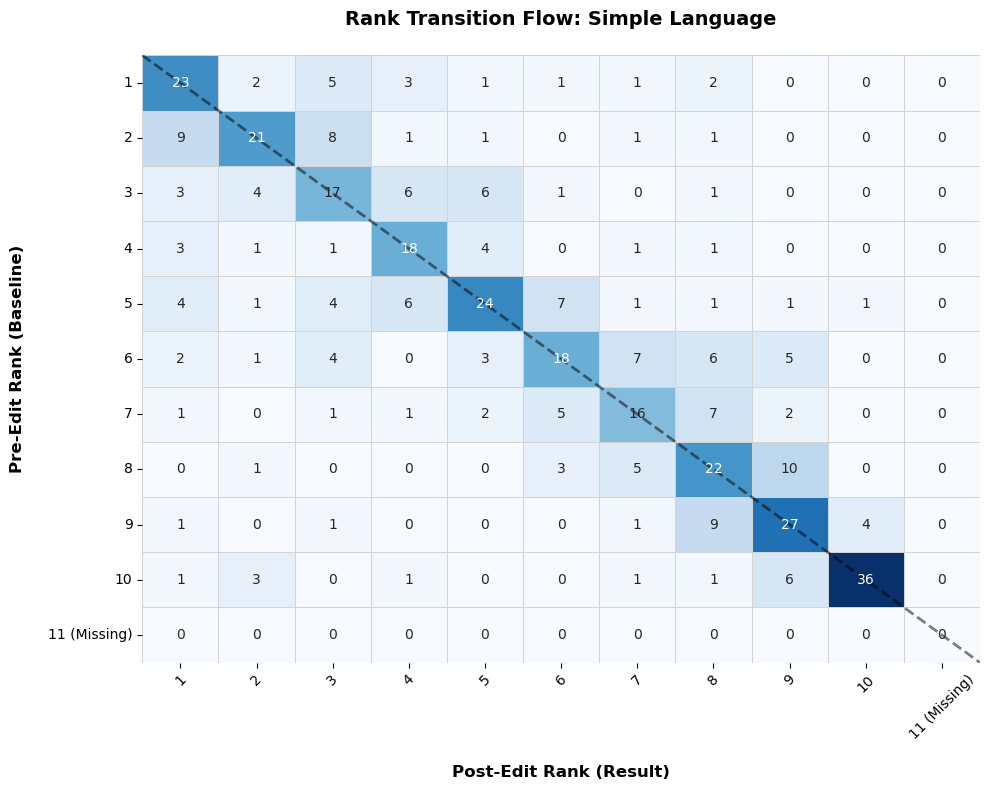

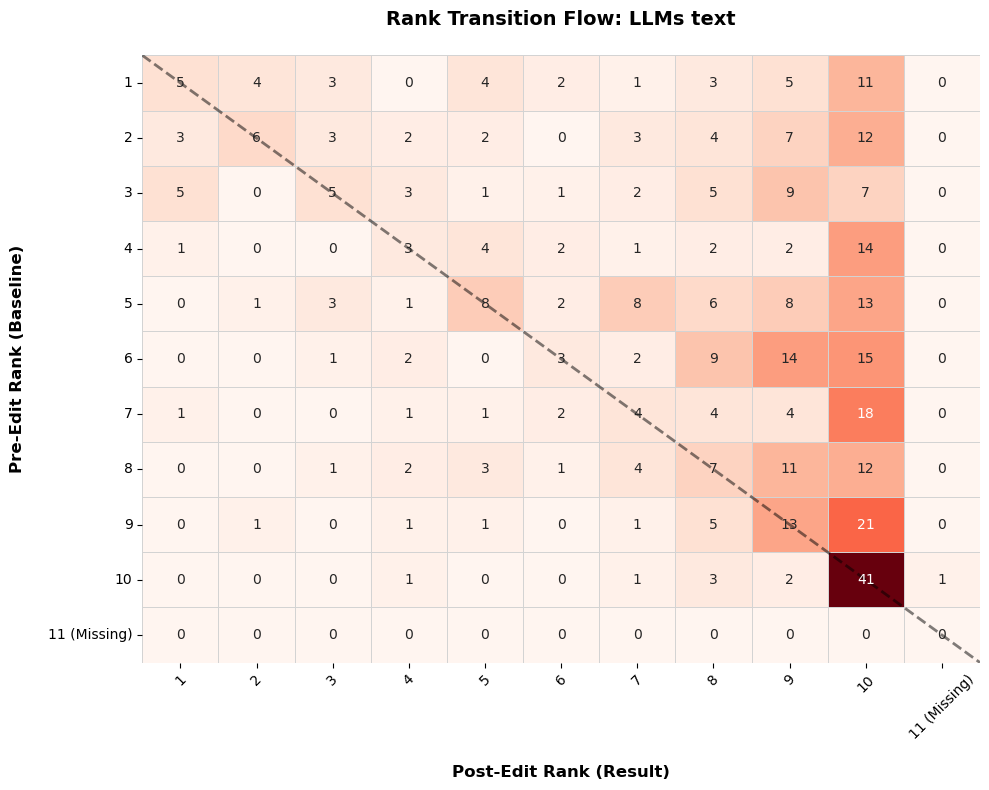

In [13]:
# Pass your final, sterile dataframe (which contains the 11s) into the function
plot_transition_matrix(strict_paired_df, 'Simple Language', color_theme="Blues")

plot_transition_matrix(strict_paired_df, 'LLMs text', color_theme="Reds")

As the above descriptives also contain data points where query runs returned missing competitor documents, we will look at the Mean Reciprocal Rank and the Hit Rate to account for that. Hit rate is defined if the target document ranks within the top 3 outputs.

## Hypothesis Testing

In [14]:
def run_wilcoxon_tests(df):
    results = []
    
    # Group by dimension
    for dimension, group in df.groupby('dimension'):
        baseline = group['baseline_rank']
        edited = group['edited_rank']
        
        # Calculate N (Total Pairs)
        n_pairs = len(group)
        
        # Calculate ties just for reporting (optional, but good to know)
        ties = len(group[baseline == edited])
        
        # Pratt keeps zeros in the ranking, so our N remains the full 411.
        valid_n = n_pairs 
        
        # Edge case safety
        if valid_n == ties:
            results.append({'Dimension': dimension, 'Strict N': n_pairs, 'Median Shift': 0.0, 'W-Stat': np.nan, 'p-value': np.nan, 'Effect Size (r)': np.nan, 'Sig.': 'No Shift'})
            continue
            
        try:
            # 1. Run the Wilcoxon Signed-Rank Test WITH PRATT MODIFICATION
            stat, p_val = wilcoxon(baseline, edited, zero_method='pratt', alternative='two-sided')
            
            # 2. The Float64 Machine Epsilon limit
            p_val = max(p_val, 1e-15) 
            
            # 3. Calculate Absolute Effect Size (r) using the FULL N
            z_stat = norm.ppf(1 - (p_val / 2))
            effect_size = z_stat / np.sqrt(valid_n)
            
            # 4. Apply the mathematical direction to the Effect Size
            shift_direction = np.sign(group['rank_shift'].mean())
            directional_effect = effect_size * shift_direction
            
            results.append({
                'Dimension': dimension,
                'Strict N': n_pairs,
                'Median Shift': group['rank_shift'].median(), 
                'W-Stat': stat,
                'p-value': p_val,
                'Effect Size (r)': directional_effect
            })
            
        except ValueError:
            results.append({'Dimension': dimension, 'Strict N': n_pairs, 'Median Shift': np.nan, 'W-Stat': np.nan, 'p-value': np.nan, 'Effect Size (r)': np.nan, 'Sig.': 'Error'})

    # Create the initial dataframe
    res_df = pd.DataFrame(results)
    
    # HOLM-BONFERRONI CORRECTION
    # 1. Apply Holm correction (fillna handles any NaN errors)
    reject, pvals_corrected, _, _ = multipletests(res_df['p-value'].fillna(1.0), alpha=0.05, method='holm')
    
    # 2. Insert the Adjusted p-value right next to the raw p-value
    res_df.insert(5, 'Adj. p-value', pvals_corrected)
    
    # 3. Calculate Significance strictly on the Adjusted p-value
    def assign_sig(p):
        if pd.isna(p): return 'Error'
        elif p < 0.001: return '*** (p<0.001)'
        elif p < 0.01: return '** (p<0.01)'
        elif p < 0.05: return '* (p<0.05)'
        else: return 'ns'
        
    res_df['Sig.'] = res_df['Adj. p-value'].apply(assign_sig)
    
    # Sort by the new Adjusted p-value first, then Effect Size
    res_df['abs_effect'] = res_df['Effect Size (r)'].abs()
    res_df = res_df.sort_values(by=['Adj. p-value', 'abs_effect'], ascending=[True, False]).drop(columns=['abs_effect'])
    
    # Format floating points
    formatted_res = res_df.round({'Median Shift': 1, 'W-Stat': 1, 'p-value': 4, 'Adj. p-value': 4, 'Effect Size (r)': 3})
    return formatted_res
    
# Execute the test
wilcoxon_table = run_wilcoxon_tests(strict_paired_df)
display(wilcoxon_table)

,Dimension,Strict N,Median Shift,W-Stat,p-value,Adj. p-value,Effect Size (r),Sig.
7,"Fluency, Citation",411,-1.0,14218.0,0.0000,0.0000,-0.395,*** (p<0.001)
8,"Fluency, Citation, Quotes",411,-1.0,13900.0,0.0000,0.0000,-0.395,*** (p<0.001)
9,"Fluency, Citation, Quotes, Statistics",411,-1.0,14449.0,0.0000,0.0000,-0.395,*** (p<0.001)
10,"Fluency, Citation, Statistics",411,-1.0,12020.5,0.0000,0.0000,-0.395,*** (p<0.001)
11,"Fluency, Quotes",411,-1.0,14317.0,0.0000,0.0000,-0.395,*** (p<0.001)
12,"Fluency, Quotes, Statistics",411,-1.0,10755.0,0.0000,0.0000,-0.395,*** (p<0.001)
13,"Fluency, Statistics",411,-1.0,14263.0,0.0000,0.0000,-0.395,*** (p<0.001)
14,LLMs text,411,-2.0,9961.5,0.0000,0.0000,-0.395,*** (p<0.001)
18,Statistics,411,0.0,14231.5,0.0000,0.0000,-0.395,*** (p<0.001)
6,Fluency,411,0.0,15342.0,0.0000,0.0000,-0.375,*** (p<0.001)


In [15]:
# calculate CI for effect sizes

# 1. The Core Bootstrapping Function (Unchanged)
def bootstrap_effect_size(group, n_iterations=10000):
    baseline = group['baseline_rank'].reset_index(drop=True)
    edited = group['edited_rank'].reset_index(drop=True)
    n = len(baseline)
    boot_effects = []
    
    # Pull the exact mathematical direction directly from your master dataframe
    true_shift_direction = np.sign(group['rank_shift'].mean())
    if true_shift_direction == 0: true_shift_direction = 1
    
    for _ in range(n_iterations):
        indices = np.random.choice(range(n), size=n, replace=True)
        boot_base = baseline.iloc[indices]
        boot_edit = edited.iloc[indices]
        
        if len(boot_base[boot_base != boot_edit]) == 0:
            continue
            
        try:
            stat, p_val = wilcoxon(boot_base, boot_edit, zero_method='pratt', alternative='two-sided')
            
            # The absolute microscopic floor
            p_val = max(p_val, 1e-300) 
            
            # Inverse Survival Function (isf) bypasses the Float64 limit
            z_stat = norm.isf(p_val / 2) 
            
            effect = (z_stat / np.sqrt(n)) * true_shift_direction
            boot_effects.append(effect)
        except ValueError:
            continue
            
    lower_ci = np.percentile(boot_effects, 2.5)
    upper_ci = np.percentile(boot_effects, 97.5)
    return lower_ci, upper_ci

ci_results = []

# Group by dimension and iterate
for dimension, group in strict_paired_df.groupby('dimension'):
    lower, upper = bootstrap_effect_size(group, n_iterations=10000)
    ci_string = f"[{lower:.3f}, {upper:.3f}]"
    
    ci_results.append({
        'Dimension': dimension,
        'Effect Size 95% CI': ci_string,
        'Lower CI': lower,
        'Upper CI': upper
    })

# Format and Output
ci_df = pd.DataFrame(ci_results)

# Sort by absolute magnitude so your biggest penalties stay at the top
ci_df['abs_lower'] = ci_df['Lower CI'].abs()
ci_df = ci_df.sort_values(by='abs_lower', ascending=False).drop(columns=['abs_lower', 'Lower CI', 'Upper CI'])

print("\nBootstrapping Complete. Here are the 95% Confidence Intervals:")
display(ci_df)


Bootstrapping Complete. Here are the 95% Confidence Intervals:


,Dimension,Effect Size 95% CI
14,LLMs text,"[-0.679, -0.558]"
12,"Fluency, Quotes, Statistics","[-0.630, -0.495]"
10,"Fluency, Citation, Statistics","[-0.586, -0.444]"
11,"Fluency, Quotes","[-0.563, -0.415]"
8,"Fluency, Citation, Quotes","[-0.552, -0.399]"
13,"Fluency, Statistics","[-0.551, -0.397]"
7,"Fluency, Citation","[-0.549, -0.398]"
9,"Fluency, Citation, Quotes, Statistics","[-0.547, -0.394]"
18,Statistics,"[-0.523, -0.370]"
6,Fluency,"[-0.456, -0.290]"


In [16]:
# merge CI into full table

# Merge the 95% CI column directly into your main Wilcoxon table
final_wilcoxon_table = pd.merge(
    wilcoxon_table, 
    ci_df[['Dimension', 'Effect Size 95% CI']], # We only pull the name and the CI column
    on='Dimension', 
    how='left'
)

# Display
display(final_wilcoxon_table)

,Dimension,Strict N,Median Shift,W-Stat,p-value,Adj. p-value,Effect Size (r),Sig.,Effect Size 95% CI
0,"Fluency, Citation",411,-1.0,14218.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.549, -0.398]"
1,"Fluency, Citation, Quotes",411,-1.0,13900.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.552, -0.399]"
2,"Fluency, Citation, Quotes, Statistics",411,-1.0,14449.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.547, -0.394]"
3,"Fluency, Citation, Statistics",411,-1.0,12020.5,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.586, -0.444]"
4,"Fluency, Quotes",411,-1.0,14317.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.563, -0.415]"
5,"Fluency, Quotes, Statistics",411,-1.0,10755.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.630, -0.495]"
6,"Fluency, Statistics",411,-1.0,14263.0,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.551, -0.397]"
7,LLMs text,411,-2.0,9961.5,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.679, -0.558]"
8,Statistics,411,0.0,14231.5,0.0000,0.0000,-0.395,*** (p<0.001),"[-0.523, -0.370]"
9,Fluency,411,0.0,15342.0,0.0000,0.0000,-0.375,*** (p<0.001),"[-0.456, -0.290]"


## Post-Hoc Analysis and Kruksal-Wallis (tbd if included)

In [19]:
# Extract the rank shifts for all 21 dimensions into a list
shift_data = []
dimension_names = []

for dimension, group in strict_paired_df.groupby('dimension'):
    shift_data.append(group['rank_shift'])
    dimension_names.append(dimension)

# Run the test by unpacking the list of series
h_stat, p_val = kruskal(*shift_data)

print(f"Kruskal-Wallis H-Statistic: {h_stat:.2f}")

if p_val < 0.001:
    print(f"p-value: < 0.001 (Exact: {p_val:.2e})")
    print("\nSignificant Result: Vertex AI does not penalize all edits equally. The algorithm has a definitive, mathematically proven hierarchy of punishments.")
elif p_val < 0.05:
    print(f"p-value: {p_val:.4f}")
    print("\nSignificant Result: The tactics have statistically different impacts.")
else:
    print(f"p-value: {p_val:.4f}")
    print("\nNo Significance: Vertex AI treats all these GEO tactics as the exact same penalty.")

Kruskal-Wallis H-Statistic: 563.13
p-value: < 0.001 (Exact: 1.66e-106)

Significant Result: Vertex AI does not penalize all edits equally. The algorithm has a definitive, mathematically proven hierarchy of punishments.


In [20]:
# 1. Run Dunn's test with a Bonferroni correction for multiple comparisons
# This creates the full 21x21 grid of p-values
dunn_matrix = sp.posthoc_dunn(
    strict_paired_df, 
    val_col='rank_shift', 
    group_col='dimension', 
    p_adjust='bonferroni'
)

# 2. Extract the comparison against the Baseline (Simple Language)
safe_comp = dunn_matrix[['Simple Language']].copy()
safe_comp.columns = ['p-value vs Simple Language']
safe_comp['Vs. Simple Language'] = np.where(
    safe_comp['p-value vs Simple Language'] < 0.05, 
    'Significantly Worse Penalty', 
    'Same Tier (No Penalty)'
)

# 3. Extract the comparison against the qorst edit (LLMs text)
nuke_comp = dunn_matrix[['LLMs text']].copy()
nuke_comp.columns = ['p-value vs LLMs text']
nuke_comp['Vs. LLMs text'] = np.where(
    nuke_comp['p-value vs LLMs text'] < 0.05, 
    'Significantly Lighter Penalty', 
    'Same Tier (Max Penalty)'
)

# 4. Join and format the table
tier_table = safe_comp.join(nuke_comp).sort_values(by='p-value vs Simple Language')

# Standardize the Simple Language self-comparison
tier_table.loc['Simple Language', 'Vs. Simple Language'] = 'Control'
tier_table.loc['LLMs text', 'Vs. LLMs text'] = 'Control'

print("Defining the algorithmic penalty brackets")
display(tier_table.round(4))

Defining the algorithmic penalty brackets


,p-value vs Simple Language,Vs. Simple Language,p-value vs LLMs text,Vs. LLMs text
LLMs text,0.0000,Significantly Worse Penalty,1.0000,Control
"Fluency, Quotes, Statistics",0.0000,Significantly Worse Penalty,0.8807,Same Tier (Max Penalty)
"Fluency, Citation, Statistics",0.0000,Significantly Worse Penalty,0.0023,Significantly Lighter Penalty
"Fluency, Quotes",0.0000,Significantly Worse Penalty,0.0009,Significantly Lighter Penalty
"Fluency, Citation",0.0000,Significantly Worse Penalty,0.0003,Significantly Lighter Penalty
"Fluency, Citation, Quotes",0.0000,Significantly Worse Penalty,0.0001,Significantly Lighter Penalty
"Fluency, Statistics",0.0000,Significantly Worse Penalty,0.0001,Significantly Lighter Penalty
"Fluency, Citation, Quotes, Statistics",0.0000,Significantly Worse Penalty,0.0001,Significantly Lighter Penalty
Statistics,0.0000,Significantly Worse Penalty,0.0000,Significantly Lighter Penalty
Content Improvement,0.0000,Significantly Worse Penalty,0.0000,Significantly Lighter Penalty


## Subgroup Stratification

In [21]:
# 1. Isolate your absolute harshest penalty
llm_df = strict_paired_df[strict_paired_df['dimension'] == 'LLMs text'].copy()

# 2. Define the exact boundary conditions (Tertiles)
def assign_tertile(rank):
    if rank <= 3: return '1. Top Tier (Ranks 1-3)'
    elif rank <= 7: return '2. Mid Tier (Ranks 4-7)'
    else: return '3. Bottom Tier (Ranks 8+)' # Fixed label to encompass Rank 11

llm_df['Baseline Tertile'] = llm_df['baseline_rank'].apply(assign_tertile)

stratified_results = []
raw_p_values = [] # We must store these to apply the Holm correction

# 3. Run the Wilcoxon test strictly within each Tertile
for tertile, group in llm_df.groupby('Baseline Tertile'):
    baseline = group['baseline_rank']
    edited = group['edited_rank']
    n_pairs = len(group)
    
    # Run Pratt-Modified Wilcoxon
    stat, p_val = wilcoxon(baseline, edited, zero_method='pratt', alternative='two-sided')
    p_val = max(p_val, 1e-300) 
    raw_p_values.append(p_val)
    
    # Calculate Directional Effect Size
    z_stat = norm.isf(p_val / 2)
    shift_direction = np.sign(group['rank_shift'].mean())
    if shift_direction == 0: shift_direction = 1
    effect_size = (z_stat / np.sqrt(n_pairs)) * shift_direction
        
    stratified_results.append({
        'Starting Position': tertile,
        'N (Queries)': n_pairs,
        'Median Shift': group['rank_shift'].median(),
        'Effect Size (r)': effect_size
    })

# 4. Apply Holm-Bonferroni Correction to the 3 Subgroup Tests
reject, pvals_corrected, _, _ = multipletests(raw_p_values, alpha=0.05, method='holm')

# 5. Append corrected p-values and assign significance stars
for i, res in enumerate(stratified_results):
    adj_p = pvals_corrected[i]
    res['Adj. p-value'] = adj_p
    
    if adj_p < 0.001: sig = '*** (p<0.001)'
    elif adj_p < 0.01: sig = '** (p<0.01)'
    elif adj_p < 0.05: sig = '* (p<0.05)'
    else: sig = 'ns'
    
    res['Sig.'] = sig

# Format and Display
stratified_df = pd.DataFrame(stratified_results).round({'Median Shift': 1, 'Adj. p-value': 4, 'Effect Size (r)': 3})

# Reorder columns for clean presentation
display(stratified_df[['Starting Position', 'N (Queries)', 'Median Shift', 'Effect Size (r)', 'Adj. p-value', 'Sig.']])

,Starting Position,N (Queries),Median Shift,Effect Size (r),Adj. p-value,Sig.
0,1. Top Tier (Ranks 1-3),118,-5.5,-0.793,0.0000,*** (p<0.001)
1,2. Mid Tier (Ranks 4-7),160,-3.0,-0.744,0.0000,*** (p<0.001)
2,3. Bottom Tier (Ranks 8+),133,0.0,0.126,0.1448,ns
